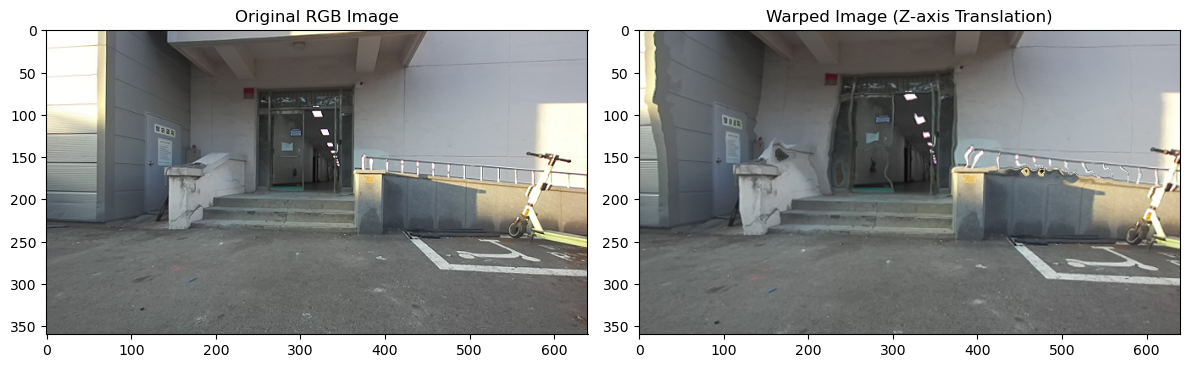

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from scipy.ndimage import map_coordinates

# 1. 이미지 불러오기
image = cv2.imread("/ssd1/jm_data/depth/ssl/monodepth2/jbnu_stereo/2025_02_28/2025_02_28_drive_0002_sync/image_02/data/0000002405.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
H, W, _ = image.shape

# 2. depth 불러오기 (grayscale → float)
depth = cv2.imread("/ssd1/jm_data/depth/ssl/depth-hints/depth_vis/video/2025_02_28_drive_0002_sync/image_02/0000002405.png", cv2.IMREAD_GRAYSCALE)
depth = cv2.resize(depth, (W, H), interpolation=cv2.INTER_LINEAR)
depth = depth.astype(np.float32) / 255.0 * 5.0  # normalize 후 scale

# 3. 내재 파라미터
f = 100.0
cx, cy = W / 2, H / 2
K = np.array([[f, 0, cx], [0, f, cy], [0, 0, 1]], dtype=np.float32)
K_inv = np.linalg.inv(K)

# 4. 픽셀 좌표 생성
x, y = np.meshgrid(np.arange(W), np.arange(H))
ones = np.ones_like(x)
pixels_h = np.stack([x, y, ones], axis=0).reshape(3, -1)  # (3, H*W)

# 5. 3D 포인트 복원
cam_coords = K_inv @ pixels_h * depth.flatten()

# 6. Z축 이동 (카메라가 앞으로 1m 이동)
cam_coords[2] -= -1

# 7. 다시 투영
pixels_proj = K @ cam_coords
pixels_proj[:2] /= pixels_proj[2:3]

# 8. 유효 좌표 마스크
x_proj = pixels_proj[0].reshape(H, W)
y_proj = pixels_proj[1].reshape(H, W)
valid_mask = (x_proj >= 0) & (x_proj < W) & (y_proj >= 0) & (y_proj < H)

# 9. 이미지 Warp
warped_image = np.zeros_like(image)
for c in range(3):
    warped_image[..., c] = map_coordinates(image[..., c], [y_proj, x_proj], order=1, mode='nearest')

# 10. 시각화
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(image)
axs[0].set_title("Original RGB Image")
axs[1].imshow(warped_image)
axs[1].set_title("Warped Image (Z-axis Translation)")
plt.tight_layout()
plt.show()
